In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Деморешение

Одна из типовых задач машинного обучения - задача предсказания выживания пассажира на Титанике. В этом материале приводится её модельное решение с помощью одного из самых простых и прозрачных методов машинного обучения - "Дерева решений".

Разберём шаги любого типового решения подобной задачи.

## Обработка данных

В качестве данных мы используем стандартный набор, который можно найти скачать например [здесь](https://www.kaggle.com/competitions/titanic/overview).

В столбцах набора данных присутствуют разные типы данных, которые можно просто и быстро посмотреть с помощью команды df.info().

In [3]:
df = pd.read_csv("tit.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


При этом известно, что модели машинного обучения в процессе обучения принимают только численные данные. Любые другие данные можно либо преобразовать в численные с помощью соответствующих инструментов, либо просто проигнорировать.

Также проигнорировать стоить колонку, которая содержит идентификационный номер. Он по сути не содержит никакой содеражетльной информации и служит только для упорядочивания данных в наборе при их хранении.

Таким образом для дальнейшей работы удалим все указанные выше столбцы.

In [6]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Sex', 'Embarked'])

In [7]:
df.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')

## Подготовка данных и обучение модели

В первую очередь необходимо разделить данные на те, что содержат признаки (X) и целевую переменную (y). Затем с помощью специального метода данные необходимо будет разбить на две подбвыорки, которые обычно называют "тренировочная" и "тестовая". Нюансов этих названий в данном материале касаться не будем.

In [8]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

Каждая модель машинного обучения обладает своими параметрами. Мы будем решать задачу классификации с помощью дерева решений. Готовая модель для обучения дерева решений есть в библиотеке sklearn.

У этой модели есть достаточно много разных параметров. Здесь мы рассмотрим только критерий (параметр для определения формулы для расчёта лучшего разбиения), максимальную глубину дерева, минимальное число элементов в листе и "статус случайного состояния".

Задав эти параметры вручную или оставив значения по умолчанию, можно переходить к обучению модели.

In [10]:
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)

## Оценка качества работы модели

После обучения модели необходимо получить предсказания на тестовом наборе данных, а затем оценить с помощью метрик результат работы обученной модели.

In [11]:
y_pred = model.predict(X_test)

In [12]:
print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred):.4f}")

Точность (Accuracy): 0.6754


In [13]:
print("Отчёт о классификации:\n", classification_report(y_test, y_pred, zero_division=0))

Отчёт о классификации:
               precision    recall  f1-score   support

           0       0.68      0.90      0.77       165
           1       0.66      0.32      0.43       103

    accuracy                           0.68       268
   macro avg       0.67      0.61      0.60       268
weighted avg       0.67      0.68      0.64       268



In [14]:
print("Матрица ошибок:\n", confusion_matrix(y_test, y_pred))

Матрица ошибок:
 [[148  17]
 [ 70  33]]


Ниже визуализированна структура получившегося дерева. Естественно её обучно не нужно выводить на экран.

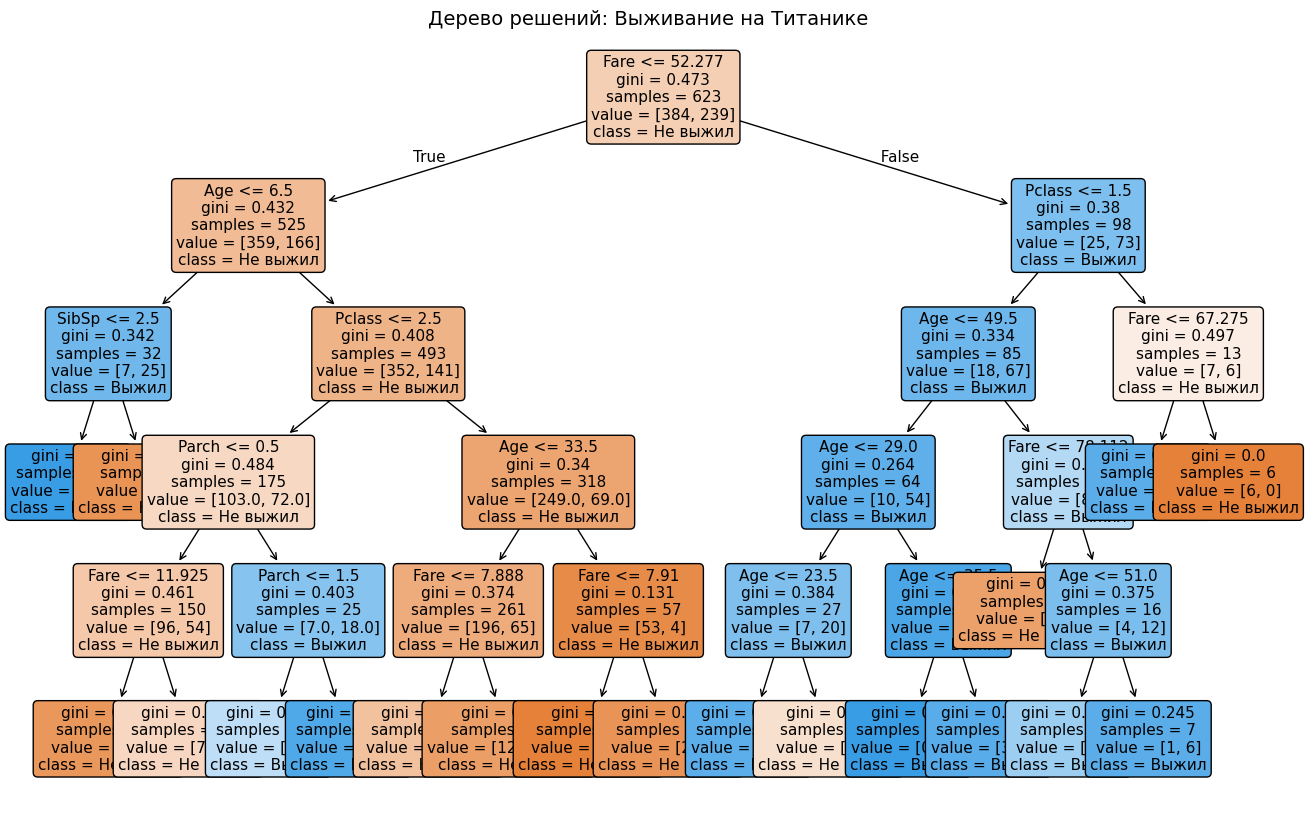

In [15]:
plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Не выжил', 'Выжил'],
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Дерево решений: Выживание на Титанике", fontsize=14)
plt.show()